In [3]:
# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import encoder to convert categorical values to one-hot vectors
from sklearn.preprocessing import OneHotEncoder

# Import tool to apply different transformers to specific columns
from sklearn.compose import ColumnTransformer

# Import Pipeline to chain preprocessing and modeling steps
from sklearn.pipeline import Pipeline

# Import ensemble models: Random Forest and Gradient Boosting classifiers
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Import logistic regression model (used as a simple baseline)
from sklearn.linear_model import LogisticRegression

# Import XGBoost classifier (powerful gradient boosting model)
from xgboost import XGBClassifier

# Import NumPy for numerical operations and matrix handling
import numpy as np  # linear algebra

# Import pandas for data loading and manipulation
import pandas as pd

# Import seaborn for statistical data visualization
import seaborn as sns

# Import matplotlib for plotting graphs and figures
import matplotlib.pyplot as plt

# Suppress all warning messages to keep the output clean
import warnings
warnings.filterwarnings('ignore')

# Import evaluation metrics to assess classification model performance
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [5]:
# Step 2: Load dataset
df = pd.read_csv("/content/global_cancer_patients_2015_2024.csv")


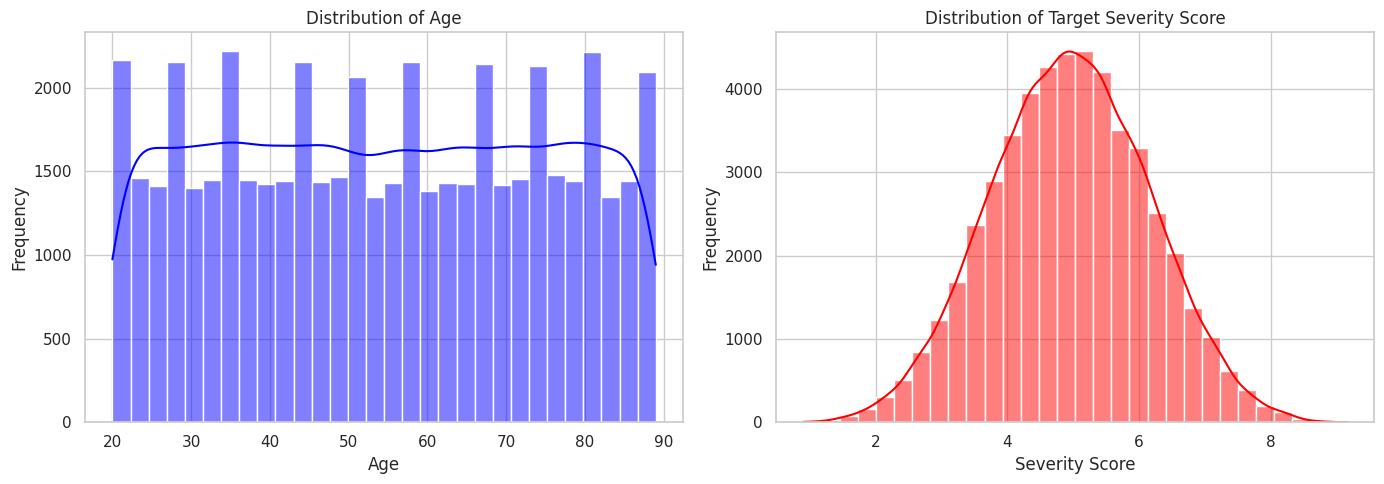

In [6]:
# Set a clean visual style
sns.set(style="whitegrid")

#  Distribution Plots
plt.figure(figsize=(14, 5))

# Age distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=30, kde=True, color='blue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Target Severity Score distribution
plt.subplot(1, 2, 2)
sns.histplot(df['Target_Severity_Score'], bins=30, kde=True, color='red')
plt.title('Distribution of Target Severity Score')
plt.xlabel('Severity Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

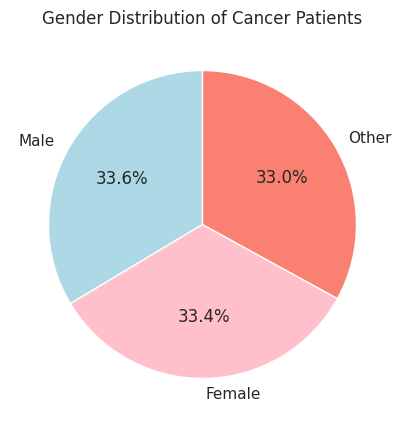

In [7]:
# Pie chart for Gender distribution
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(5, 5))
gender_counts.plot.pie(autopct='%1.1f%%', colors=['lightblue','pink', 'salmon'], startangle=90)
plt.title('Gender Distribution of Cancer Patients')
plt.ylabel('')
plt.show()

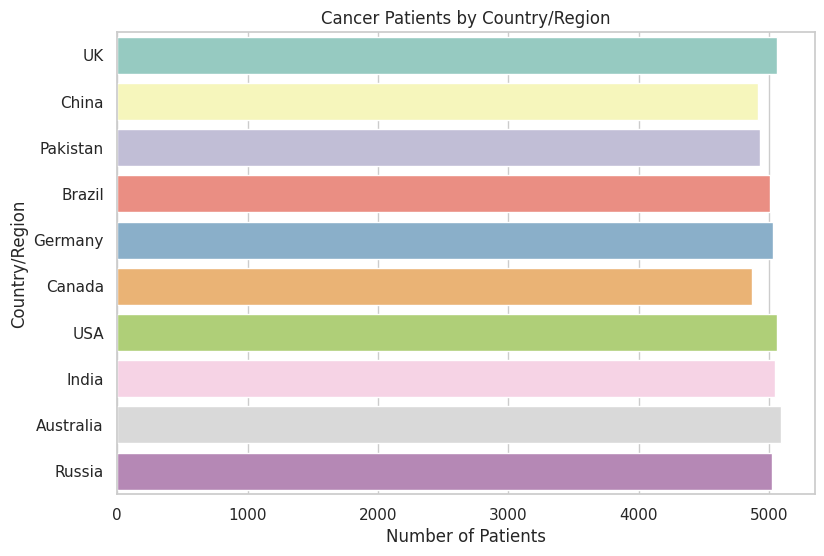

In [9]:
# Bar plot for Country/Region distribution
plt.figure(figsize=(9, 6))
sns.countplot(y='Country_Region', data=df, palette='Set3')
plt.title('Cancer Patients by Country/Region')
plt.xlabel('Number of Patients')
plt.ylabel('Country/Region')
plt.show()

In [ ]:
# Define features and target
target = 'Target_Severity_Score'
features = ['Age', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Treatment_Cost_USD']
categorical_features = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']

# Bin continuous target into classes (e.g., 0: Low, 1: Medium, 2: High)
def bin_severity(score):
    if score <= 3:
        return 0  # Low
    elif score <= 6:
        return 1  # Medium
    else:
        return 2  # High

df['Severity_Class'] = df[target].apply(bin_severity)

# Update target to classification
target_class = 'Severity_Class'

# Split data
X = df[features + categorical_features]
#features + categorical_features combines the two lists into one.
y = df[target_class]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessor for numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
##ColumnTransformer lets you:

#Apply one kind of transformation to numeric columns

#Apply another kind to categorical columns

#Keep it all in one unified pipeline


----- RandomForest -----
Accuracy: 0.916
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.42      0.59       517
           1       0.90      1.00      0.95      7562
           2       0.99      0.73      0.84      1921

    accuracy                           0.92     10000
   macro avg       0.96      0.71      0.79     10000
weighted avg       0.92      0.92      0.91     10000



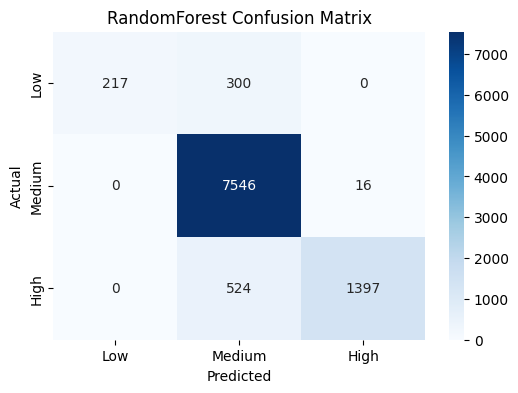


----- LogisticRegression -----
Accuracy: 0.897
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86       517
           1       0.92      0.95      0.93      7562
           2       0.79      0.73      0.76      1921

    accuracy                           0.90     10000
   macro avg       0.87      0.83      0.85     10000
weighted avg       0.89      0.90      0.90     10000



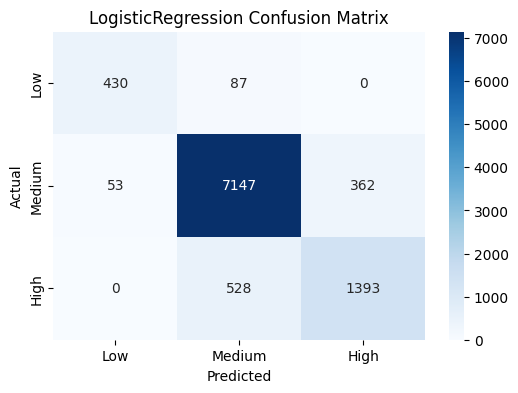


----- XGBoost -----
Accuracy: 0.973
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.85      0.90       517
           1       0.98      0.99      0.98      7562
           2       0.96      0.95      0.95      1921

    accuracy                           0.97     10000
   macro avg       0.97      0.93      0.95     10000
weighted avg       0.97      0.97      0.97     10000



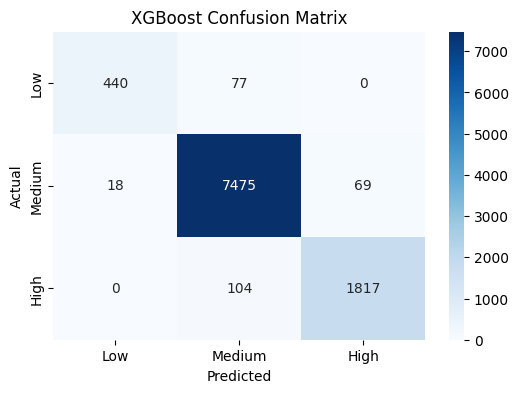


----- GradientBoosting -----
Accuracy: 0.945
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.61      0.75       517
           1       0.94      1.00      0.96      7562
           2       0.98      0.83      0.90      1921

    accuracy                           0.94     10000
   macro avg       0.97      0.81      0.87     10000
weighted avg       0.95      0.94      0.94     10000



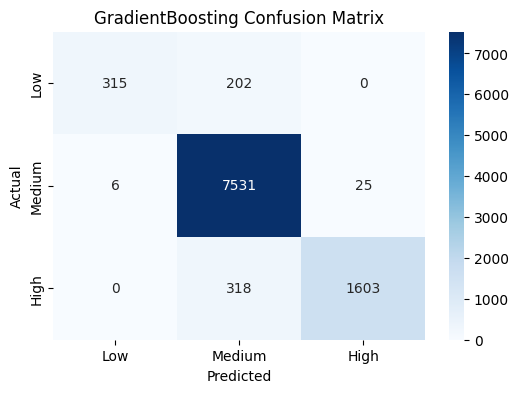

In [ ]:
# Define classifiers to test
classifiers = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    #n_estimators=100: Use 100 decision trees in the forest.
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    #max_iter=1000: Increases the number of iterations (used when the model needs more steps to converge).
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    #use_label_encoder=False: Avoids deprecation warnings (new XGBoost versions don’t need label encoding).
    #eval_metric='mlogloss': Sets the evaluation metric to log loss (useful for multiclass classification).
    'GradientBoosting': GradientBoostingClassifier(random_state=42)

}

# Loop through classifiers
for name, clf in classifiers.items():
    print(f"\n----- {name} -----")

    # Build pipeline
    #The Pipeline object from sklearn.pipeline lets you chain together multiple steps (like preprocessing + modeling) into one single object.
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ]).
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f"Accuracy: {acc:.3f}")
    print("Classification Report:\n", report)

    # Plot confusion matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()